In [1]:
import numpy              as np
import matplotlib.pyplot  as plt
import seaborn            as sns
import os

from pymatgen.io.vasp.outputs import Vasprun
from pymatgen.io.vasp.outputs import Locpot

sns.set_theme()

First we compute linear macroscopic average potential for bulk and each slab. Then we compute the band alignment for each slab.

The linear macroscopic average potential is computed as:

$echo -e "426" | ~/vaspkit.1.3.5/bin/vaspkit

The position of the valence band with respect to vacuum level is computed as:

\begin{equation}
    VBM = VMB_{DFT} - V_{bulk} + (V_{slab} - V_{vacuum})
\end{equation}

In [2]:
# Define name of reference folder which stores the energies of each slab
#slab_folder = 'input/slabs/BiSeI-slab'
slab_folder = '/Users/cibran/Desktop/slabs/SbSBr-slab/alignments'

# Ratio to discard from the edges for averaging
discard_ratio = 0.25

# Bulk

In [3]:
bulk_folder = f'{slab_folder}/bulk'

locpot = Locpot.from_file(f'{bulk_folder}/LOCPOT')
linear_mac_pot = locpot.get_average_along_axis(2)

/Users/cibran/work/UPC/SlabOptimization/.venv/lib/python3.13/site-packages/pymatgen/io/vasp/outputs.py:3493: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, mode="rt") as file:


In [4]:
# Load vasprun
vasprun = Vasprun(f'{bulk_folder}/vasprun.xml')

# Get band structure
band_structure = vasprun.get_band_structure()

# Get valence band maximum and band gap
valence_band_DFT = band_structure.get_vbm()["energy"]
band_gap         = band_structure.get_band_gap()["energy"]

/Users/cibran/work/UPC/SlabOptimization/.venv/lib/python3.13/site-packages/pymatgen/io/vasp/outputs.py:312: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, mode="rt") as file:
/Users/cibran/work/UPC/SlabOptimization/.venv/lib/python3.13/site-packages/pymatgen/io/vasp/inputs.py:2655: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, mode="rt") as file:
/Users/cibran/work/UPC/SlabOptimization/.venv/lib/python3.13/site-packages/pymatgen/io/vasp/inputs.py:1492: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, mode="rt") as file:


In [5]:
mac_avg_pot_bulk = np.mean(linear_mac_pot)

np.savetxt(f'{bulk_folder}/macroscopic_average_potential', [mac_avg_pot_bulk])

print(f'Mean value: {mac_avg_pot_bulk}')

Mean value: -7.977613879321662


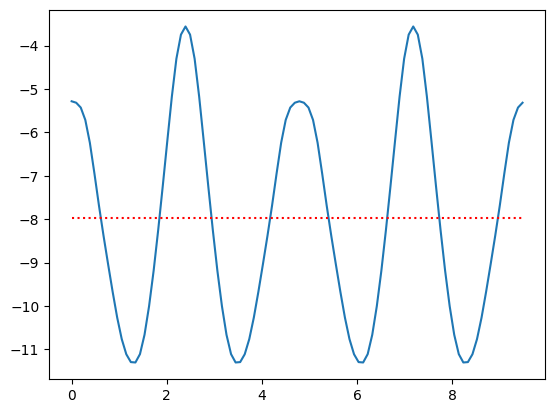

In [6]:
x_label = np.arange(len(linear_mac_pot)) * vasprun.final_structure.lattice.c / len(linear_mac_pot)
plt.plot(x_label, linear_mac_pot, label='Linear average potential')
plt.plot([x_label[0], x_label[-1]], [mac_avg_pot_bulk, mac_avg_pot_bulk], ':r', label='Mean value')

plt.savefig(f'{bulk_folder}/macroscopic_average_potential.pdf', bbox_inches='tight')
plt.show()

# Slab

In [7]:
band_gap

2.2052

/Users/cibran/work/UPC/SlabOptimization/.venv/lib/python3.13/site-packages/pymatgen/io/vasp/outputs.py:3493: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, mode="rt") as file:


/Users/cibran/Desktop/slabs/SbSBr-slab/alignments/1_1_2_i_57
	Valence band: -6.083945361333859
	Conduction band: -3.8787453613338587


/Users/cibran/work/UPC/SlabOptimization/.venv/lib/python3.13/site-packages/pymatgen/io/vasp/outputs.py:312: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, mode="rt") as file:
/Users/cibran/work/UPC/SlabOptimization/.venv/lib/python3.13/site-packages/pymatgen/io/vasp/inputs.py:2655: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, mode="rt") as file:


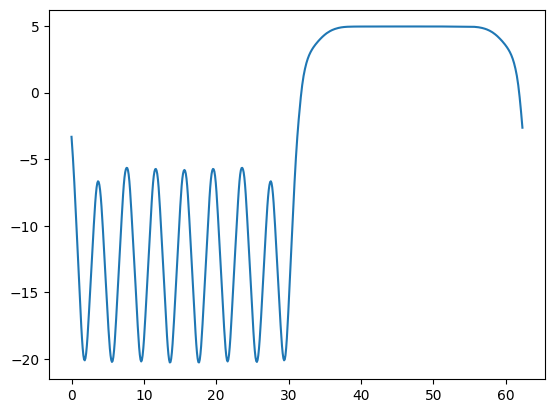

/Users/cibran/Desktop/slabs/SbSBr-slab/alignments/2_1_2_i_31
	Valence band: -5.882949486559695
	Conduction band: -3.6777494865596947


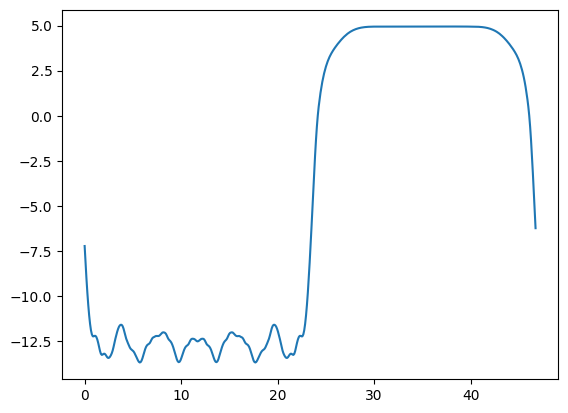

/Users/cibran/Desktop/slabs/SbSBr-slab/alignments/1_2_2_i_48
	Valence band: -6.088645297695859
	Conduction band: -3.8834452976958587


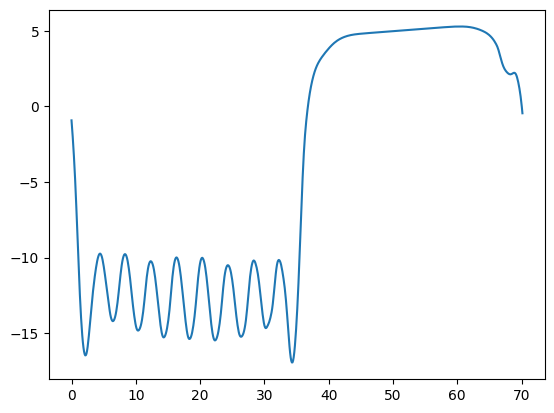

/Users/cibran/Desktop/slabs/SbSBr-slab/alignments/1_2_2_i_49
	Valence band: -6.158757381182396
	Conduction band: -3.9535573811823963


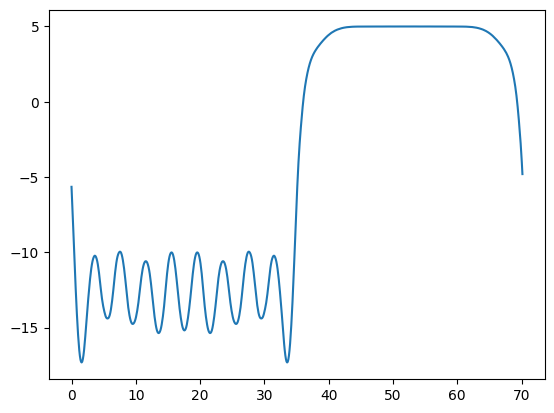

/Users/cibran/Desktop/slabs/SbSBr-slab/alignments/0_1_1_i_18
	Valence band: -6.398593656787714
	Conduction band: -4.193393656787714


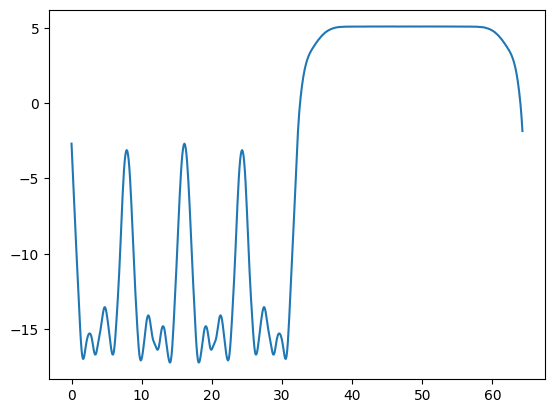

/Users/cibran/Desktop/slabs/SbSBr-slab/alignments/2_1_0_i_41
	Valence band: -6.027089018815359
	Conduction band: -3.821889018815359


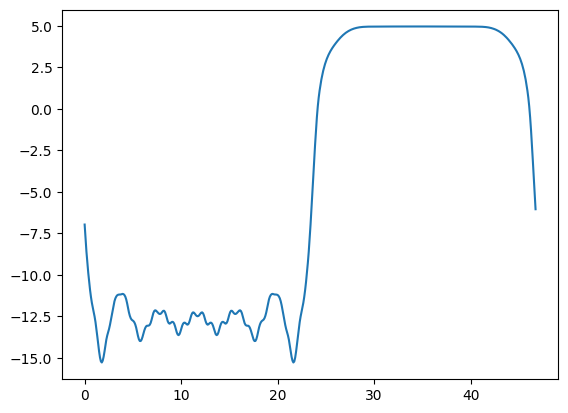

/Users/cibran/Desktop/slabs/SbSBr-slab/alignments/2_0_1_i_44
	Valence band: -6.036471169103085
	Conduction band: -3.831271169103085


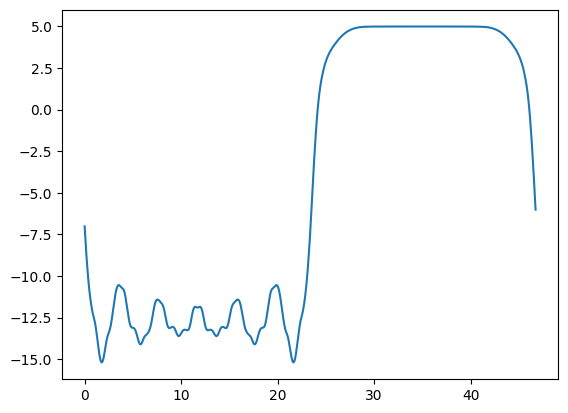

/Users/cibran/Desktop/slabs/SbSBr-slab/alignments/0_1_0_i_21
	Valence band: -5.606986351624886
	Conduction band: -3.4017863516248856


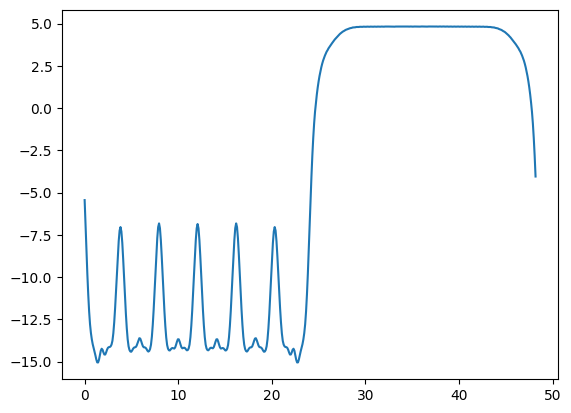

/Users/cibran/Desktop/slabs/SbSBr-slab/alignments/0_2_1_i_63
	Valence band: -6.399588486441133
	Conduction band: -4.194388486441133


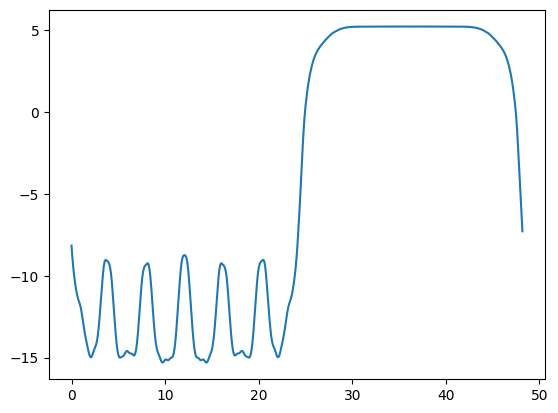

/Users/cibran/Desktop/slabs/SbSBr-slab/alignments/ranking-energies-as-in-slabs


FileNotFoundError: [Errno 2] No such file or directory: '/Users/cibran/Desktop/slabs/SbSBr-slab/alignments/ranking-energies-as-in-slabs/LOCPOT'

In [8]:
# Iterate over slabs
for miller_index_str in os.listdir(slab_folder):
    # Define current folder
    miller_folder = f'{slab_folder}/{miller_index_str}'

    # Skip in case it is not a folder or it is the bulk folder
    if (not os.path.isdir(miller_folder)) or (miller_index_str == 'bulk'):
        continue

    print(miller_folder)

    # Load planar average potential
    locpot = Locpot.from_file(f'{miller_folder}/LOCPOT')
    linear_mac_pot = locpot.get_average_along_axis(2)

    # Divide into bulk and vacuum
    mid_idx = int(0.5*len(linear_mac_pot))

    bulk_mac_pot   = linear_mac_pot[:mid_idx]
    vacuum_mac_pot = linear_mac_pot[mid_idx:]

    vasprun = Vasprun(f'{miller_folder}/vasprun.xml')
    x_label = np.arange(len(linear_mac_pot)) * vasprun.final_structure.lattice.c / len(linear_mac_pot)
    plt.plot(x_label, linear_mac_pot, label='Slab')

    # Bulk
    idx_ref = int(discard_ratio*len(bulk_mac_pot))
    bulk_valid_mac_pot = bulk_mac_pot[idx_ref:-idx_ref]
    mean_avg_pot_bulk = np.mean(bulk_valid_mac_pot)

    #print(f'\tPotential in bulk: {mean_avg_pot_bulk}')
    plt.plot([x_label[:mid_idx][idx_ref:-idx_ref][0], x_label[:mid_idx][idx_ref:-idx_ref][-1]], [mean_avg_pot_bulk, mean_avg_pot_bulk], ':r', label='Bulk')

    # Vacuum
    idx_ref = int(discard_ratio*len(vacuum_mac_pot))
    vacuum_valid_mac_pot = vacuum_mac_pot[idx_ref:-idx_ref]
    mean_avg_pot_vacuum = np.mean(vacuum_valid_mac_pot)

    #print(f'\tPotential in vacuum: {mean_avg_pot_vacuum}')
    plt.plot([x_label[mid_idx:][idx_ref:-idx_ref][0], x_label[mid_idx:][idx_ref:-idx_ref][-1]], [mean_avg_pot_vacuum, mean_avg_pot_vacuum], ':r', label='Vacuum')

    # Save the data
    np.savetxt(f'{miller_folder}/macroscopic_average_potential', [mean_avg_pot_bulk, mean_avg_pot_vacuum])

    # Compute band alignments referred to vacuum
    valence_band    = valence_band_DFT + mean_avg_pot_bulk - mac_avg_pot_bulk + 0 - mean_avg_pot_vacuum
    conduction_band = valence_band + band_gap

    # Save the data
    np.savetxt(f'{miller_folder}/valence_band',    [valence_band])
    np.savetxt(f'{miller_folder}/conduction_band', [conduction_band])

    print(f'\tValence band: {valence_band}')
    print(f'\tConduction band: {conduction_band}')

    plt.savefig(f'{miller_folder}/macroscopic_average_potential.pdf', bbox_inches='tight')
    plt.show()